# Football Career Performance Analysis

This project explores the career journey of a professional football athlete through data analysis and visualization.

The dataset was manually designed using publicly available football statistics and career information for educational and analytical purposes.

In [2]:
# 1. Import Libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 2. Load CSV file
football_df = pd.read_csv("/content/football_player_career.csv")
football_df.head()


,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards
0,2009,Liga Paulista,Santos,28,9,3,1,Youth Prodigy,17,2100,Healthy,7.0,2
1,2009,Copa do Brasil,Santos,12,4,2,0,Youth Prodigy,17,900,Healthy,7.1,1
2,2009,Brasileirao,Santos,8,1,0,0,Youth Prodigy,17,540,Healthy,6.8,1
3,2010,Liga Paulista,Santos,19,20,6,1,Youth Prodigy,18,1620,Healthy,8.3,3
4,2010,Copa do Brasil,Santos,14,12,4,1,Youth Prodigy,18,1200,Healthy,8.1,2


In [4]:
# 3.Check Duplicate Rows
football_df.duplicated().sum()

np.int64(0)

In [5]:
# 4. Check Zero Vlaues
(football_df ['goals']== 0).sum()

np.int64(5)

In [6]:
# View data tyes
football_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          50 non-null     int64  
 1   competition     50 non-null     object 
 2   club            50 non-null     object 
 3   appearances     50 non-null     int64  
 4   goals           50 non-null     int64  
 5   assists         50 non-null     int64  
 6   trophies_won    50 non-null     int64  
 7   phase           50 non-null     object 
 8   age             50 non-null     int64  
 9   minutes_played  50 non-null     int64  
 10  injury_status   50 non-null     object 
 11  match_rating    50 non-null     float64
 12  yellow_cards    50 non-null     int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 5.2+ KB


In [7]:
# View Basic Statistics
football_df.describe()

,season,appearances,goals,assists,trophies_won,age,minutes_played,match_rating,yellow_cards
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2016.640000,11.10000,7.120000,3.800000,0.540000,24.640000,896.200000,7.772000,1.740000
std,4.809684,7.15499,6.365212,3.238795,0.503457,4.809684,577.075279,0.614465,1.321873
min,2009.000000,2.00000,0.000000,0.000000,0.000000,17.000000,160.000000,6.400000,0.000000
25%,2013.000000,5.25000,2.000000,1.000000,0.000000,21.000000,420.000000,7.425000,1.000000
50%,2016.000000,9.00000,5.000000,3.000000,1.000000,24.000000,720.000000,7.850000,2.000000
75%,2020.750000,15.75000,10.750000,5.750000,1.000000,28.750000,1312.500000,8.175000,2.000000
max,2025.000000,28.00000,22.000000,13.000000,1.000000,33.000000,2160.000000,9.000000,5.000000


In [8]:
# check Dataset Size
football_df.shape


(50, 13)

In [9]:
num_cols = football_df.shape[0]
num_cols

50

In [10]:
# View Specific Columns
# Slice fist few columsn
result_1 = football_df.loc[:, 'season': 'club']
result_1.head()

,season,competition,club
0,2009,Liga Paulista,Santos
1,2009,Copa do Brasil,Santos
2,2009,Brasileirao,Santos
3,2010,Liga Paulista,Santos
4,2010,Copa do Brasil,Santos


In [11]:
# Veiw Specific Rows
# Fist three rows
view_rows = football_df.loc[0:2, :]
view_rows


,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards
0,2009,Liga Paulista,Santos,28,9,3,1,Youth Prodigy,17,2100,Healthy,7.0,2
1,2009,Copa do Brasil,Santos,12,4,2,0,Youth Prodigy,17,900,Healthy,7.1,1
2,2009,Brasileirao,Santos,8,1,0,0,Youth Prodigy,17,540,Healthy,6.8,1


In [12]:
# View non-conitguosu rows
checkr_c = football_df.loc[[10, 20, 30, 40 ], ['competition', 'goals', 'assists']]
checkr_c

,competition,goals,assists
10,Copa Libertadores,14,6
20,Champions League,10,6
30,Champions League,6,4
40,Ligue 1,13,11


In [13]:
#Access Last Row
football_df.iloc[num_cols-1, :]

,49
season,2025
competition,Liga Paulista
club,Santos
appearances,2
goals,0
assists,0
trophies_won,0
phase,Return
age,33
minutes_played,160


In [14]:
# Check Unique Values
# Unique clubs
football_df['club'].unique()


array(['Santos', 'Barcelona', 'PSG', 'Al-Hilal'], dtype=object)

In [15]:
#Unique competitions
football_df['competition'].unique()

array(['Liga Paulista', 'Copa do Brasil', 'Brasileirao',
       'Copa Libertadores', 'La Liga', 'Copa del Rey', 'Champions League',
       'Club World Cup', 'Supercopa de España', 'Ligue 1',
       'Coupe de France', 'Saudi Pro League', "King's Cup",
       'Copa Sudamericana'], dtype=object)

In [16]:
#uUnique career phases
football_df['phase'].unique()

array(['Youth Prodigy', 'Rise to Europe', 'MSN Peak', 'PSG Era',
       'Injury Shadow', 'Decline', 'Return'], dtype=object)

In [17]:
# Count Values
#Count career phases
football_df['phase'].value_counts()

,count
phase,
PSG Era,15
Youth Prodigy,12
MSN Peak,8
Rise to Europe,6
Decline,4
Return,3
Injury Shadow,2


In [18]:
#Count injury phases
football_df['injury_status'].value_counts()

,count
injury_status,
Healthy,37
Major Injury,6
Minor Injury,4
Recovering,3


In [19]:
# Calculate Basic Statistics

In [20]:
#Average Goasl
avg_goals = football_df['goals'].mean()
avg_goals


#Maximun goals
max_goals = football_df['goals'].max()
max_goals

#Minuimun goals
min_goals = football_df['goals'].min()
min_goals

print("Average Goals: ", avg_goals)
print("Maximum Goals: ", max_goals)
print("Minimum Goals: ", min_goals)

Average Goals:  7.12
Maximum Goals:  22
Minimum Goals:  0


In [21]:
# Match Rating Analysis
avg_rating = football_df['match_rating'].mean()
avg_rating

max_rating = football_df['match_rating'].max()
max_rating

min_rating = football_df['match_rating'].min()
min_rating

print("Average Rating: ", avg_rating)
print("Maximum Rating: ", max_rating)
print("Minimum Rating: ", min_rating)

Average Rating:  7.771999999999999
Maximum Rating:  9.0
Minimum Rating:  6.4


In [22]:
# Multiple Averages
avg_assists = football_df['assists'].mean()
avg_minutes = football_df['minutes_played'].mean()


print("Average Assists: ", avg_assists)
print("Average Minutes Played: ", avg_minutes)

Average Assists:  3.8
Average Minutes Played:  896.2


In [23]:
# Create New Calculated Column
# Total contribution
football_df['contribution'] = football_df['goals'] + football_df ['assists']
football_df.head()

,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards,contribution
0,2009,Liga Paulista,Santos,28,9,3,1,Youth Prodigy,17,2100,Healthy,7.0,2,12
1,2009,Copa do Brasil,Santos,12,4,2,0,Youth Prodigy,17,900,Healthy,7.1,1,6
2,2009,Brasileirao,Santos,8,1,0,0,Youth Prodigy,17,540,Healthy,6.8,1,1
3,2010,Liga Paulista,Santos,19,20,6,1,Youth Prodigy,18,1620,Healthy,8.3,3,26
4,2010,Copa do Brasil,Santos,14,12,4,1,Youth Prodigy,18,1200,Healthy,8.1,2,16


In [24]:
#Greate Goal Ratio Column
football_df['goal_ratio'] = football_df['goals'] / football_df['appearances']
football_df.head()

,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards,contribution,goal_ratio
0,2009,Liga Paulista,Santos,28,9,3,1,Youth Prodigy,17,2100,Healthy,7.0,2,12,0.321429
1,2009,Copa do Brasil,Santos,12,4,2,0,Youth Prodigy,17,900,Healthy,7.1,1,6,0.333333
2,2009,Brasileirao,Santos,8,1,0,0,Youth Prodigy,17,540,Healthy,6.8,1,1,0.125000
3,2010,Liga Paulista,Santos,19,20,6,1,Youth Prodigy,18,1620,Healthy,8.3,3,26,1.052632
4,2010,Copa do Brasil,Santos,14,12,4,1,Youth Prodigy,18,1200,Healthy,8.1,2,16,0.857143


In [25]:
# Sort DATA - Top Goal Performances

top_goal_performance = football_df.sort_values(by='goals',
                                               ascending=False
                                               ).head(5)
top_goal_performance.head()

,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards,contribution,goal_ratio
15,2014,La Liga,Barcelona,27,22,11,0,Rise to Europe,22,2160,Healthy,8.0,5,33,0.814815
18,2015,La Liga,Barcelona,24,22,8,1,MSN Peak,23,2040,Healthy,8.9,3,30,0.916667
9,2012,Liga Paulista,Santos,17,20,7,1,Youth Prodigy,20,1440,Healthy,8.7,3,27,1.176471
3,2010,Liga Paulista,Santos,19,20,6,1,Youth Prodigy,18,1620,Healthy,8.3,3,26,1.052632
26,2017,Ligue 1,PSG,20,19,13,1,PSG Era,25,1600,Healthy,8.3,4,32,0.950000


In [26]:
# Sort Data - Best Match Rating

top_ratings = football_df.sort_values(by='match_rating',
                                      ascending=False
                                      ).head(5)
top_ratings.head()

,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards,contribution,goal_ratio
20,2015,Champions League,Barcelona,12,10,6,1,MSN Peak,23,1020,Healthy,9.0,2,16,0.833333
18,2015,La Liga,Barcelona,24,22,8,1,MSN Peak,23,2040,Healthy,8.9,3,30,0.916667
9,2012,Liga Paulista,Santos,17,20,7,1,Youth Prodigy,20,1440,Healthy,8.7,3,27,1.176471
19,2015,Copa del Rey,Barcelona,7,7,2,1,MSN Peak,23,600,Healthy,8.7,1,9,1.000000
21,2015,Club World Cup,Barcelona,2,2,1,1,MSN Peak,23,180,Healthy,8.6,0,3,1.000000


In [27]:
# Sort Data - Lowest Match Ratings
lowest_ratings = football_df.sort_values(by='match_rating',
                                         ascending=True
                                         ).head(5)
lowest_ratings.head()

,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards,contribution,goal_ratio
46,2024,Brasileirao,Santos,2,0,0,0,Decline,32,160,Major Injury,6.4,0,0,0.000
45,2024,Saudi Pro League,Al-Hilal,4,0,1,0,Decline,32,320,Major Injury,6.5,1,1,0.000
44,2023,King's Cup,Al-Hilal,2,0,1,1,Decline,31,160,Major Injury,6.6,0,1,0.000
2,2009,Brasileirao,Santos,8,1,0,0,Youth Prodigy,17,540,Healthy,6.8,1,1,0.125
43,2023,Saudi Pro League,Al-Hilal,5,1,2,1,Decline,31,400,Major Injury,6.9,1,3,0.200


In [28]:
# Group Data by Club

club_goals = football_df.groupby('club')['goals'].sum()
club_goals.head()

,goals
club,
Al-Hilal,1
Barcelona,117
PSG,111
Santos,127


In [29]:
# Group Data By Competition

competition_ratings = football_df.groupby(
    'competition')['match_rating'].mean()
competition_ratings.head()


,match_rating
competition,
Brasileirao,7.383333
Champions League,7.800000
Club World Cup,8.600000
Copa Libertadores,8.350000
Copa Sudamericana,7.700000


In [30]:
# Group by Data by Carrer Phase

phase_goals = football_df.groupby('phase')['goals'].sum()
phase_goals

,goals
phase,
Decline,1
Injury Shadow,13
MSN Peak,71
PSG Era,98
Return,6
Rise to Europe,46
Youth Prodigy,121


In [31]:
# Total Goals and Assists
total_goals = football_df['goals'].sum()
total_assists = football_df['assists'].sum()

print("Total Goals: ", total_goals)
print("Total Assists: ", total_assists)

Total Goals:  356
Total Assists:  190


In [32]:
# Analyze Trophies
most_trophies = football_df.sort_values(by='trophies_won',
                                        ascending=False
                                        ).head(5)
most_trophies.head()

,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards,contribution,goal_ratio
0,2009,Liga Paulista,Santos,28,9,3,1,Youth Prodigy,17,2100,Healthy,7.0,2,12,0.321429
3,2010,Liga Paulista,Santos,19,20,6,1,Youth Prodigy,18,1620,Healthy,8.3,3,26,1.052632
9,2012,Liga Paulista,Santos,17,20,7,1,Youth Prodigy,20,1440,Healthy,8.7,3,27,1.176471
4,2010,Copa do Brasil,Santos,14,12,4,1,Youth Prodigy,18,1200,Healthy,8.1,2,16,0.857143
7,2011,Copa Libertadores,Santos,13,8,6,1,Youth Prodigy,19,1080,Healthy,8.2,2,14,0.615385


In [33]:
# Summary of contribution column
football_df['contribution'].describe()

,contribution
count,50.000000
mean,10.920000
std,9.343425
min,0.000000
25%,3.000000
50%,9.000000
75%,16.000000
max,33.000000


In [34]:

# Filter Specific Club
santos_data = football_df[football_df['club']=='Santos']
santos_data.head()

,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards,contribution,goal_ratio
0,2009,Liga Paulista,Santos,28,9,3,1,Youth Prodigy,17,2100,Healthy,7.0,2,12,0.321429
1,2009,Copa do Brasil,Santos,12,4,2,0,Youth Prodigy,17,900,Healthy,7.1,1,6,0.333333
2,2009,Brasileirao,Santos,8,1,0,0,Youth Prodigy,17,540,Healthy,6.8,1,1,0.125000
3,2010,Liga Paulista,Santos,19,20,6,1,Youth Prodigy,18,1620,Healthy,8.3,3,26,1.052632
4,2010,Copa do Brasil,Santos,14,12,4,1,Youth Prodigy,18,1200,Healthy,8.1,2,16,0.857143


In [35]:
# Fliter heathy Player REcords

healty_data = football_df[football_df['injury_status'] == 'Healthy']
healty_data.head()


,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards,contribution,goal_ratio
0,2009,Liga Paulista,Santos,28,9,3,1,Youth Prodigy,17,2100,Healthy,7.0,2,12,0.321429
1,2009,Copa do Brasil,Santos,12,4,2,0,Youth Prodigy,17,900,Healthy,7.1,1,6,0.333333
2,2009,Brasileirao,Santos,8,1,0,0,Youth Prodigy,17,540,Healthy,6.8,1,1,0.125000
3,2010,Liga Paulista,Santos,19,20,6,1,Youth Prodigy,18,1620,Healthy,8.3,3,26,1.052632
4,2010,Copa do Brasil,Santos,14,12,4,1,Youth Prodigy,18,1200,Healthy,8.1,2,16,0.857143


In [36]:
#Filter high Performance Mathces
high_rating = football_df[football_df['match_rating'] >= 8.0]
high_rating.head()

,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards,contribution,goal_ratio
3,2010,Liga Paulista,Santos,19,20,6,1,Youth Prodigy,18,1620,Healthy,8.3,3,26,1.052632
4,2010,Copa do Brasil,Santos,14,12,4,1,Youth Prodigy,18,1200,Healthy,8.1,2,16,0.857143
7,2011,Copa Libertadores,Santos,13,8,6,1,Youth Prodigy,19,1080,Healthy,8.2,2,14,0.615385
9,2012,Liga Paulista,Santos,17,20,7,1,Youth Prodigy,20,1440,Healthy,8.7,3,27,1.176471
10,2012,Copa Libertadores,Santos,14,14,6,0,Youth Prodigy,20,1200,Healthy,8.5,2,20,1.000000


In [37]:
# Top three contribution Seasons
top_contribution = football_df.sort_values(by='contribution',
                                         ascending=False
                                         ).head(3)
top_contribution.head(3)

,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards,contribution,goal_ratio
15,2014,La Liga,Barcelona,27,22,11,0,Rise to Europe,22,2160,Healthy,8.0,5,33,0.814815
26,2017,Ligue 1,PSG,20,19,13,1,PSG Era,25,1600,Healthy,8.3,4,32,0.950000
18,2015,La Liga,Barcelona,24,22,8,1,MSN Peak,23,2040,Healthy,8.9,3,30,0.916667


In [38]:
#Final Data Review
football_df.head(10)

,season,competition,club,appearances,goals,assists,trophies_won,phase,age,minutes_played,injury_status,match_rating,yellow_cards,contribution,goal_ratio
0,2009,Liga Paulista,Santos,28,9,3,1,Youth Prodigy,17,2100,Healthy,7.0,2,12,0.321429
1,2009,Copa do Brasil,Santos,12,4,2,0,Youth Prodigy,17,900,Healthy,7.1,1,6,0.333333
2,2009,Brasileirao,Santos,8,1,0,0,Youth Prodigy,17,540,Healthy,6.8,1,1,0.125000
3,2010,Liga Paulista,Santos,19,20,6,1,Youth Prodigy,18,1620,Healthy,8.3,3,26,1.052632
4,2010,Copa do Brasil,Santos,14,12,4,1,Youth Prodigy,18,1200,Healthy,8.1,2,16,0.857143
5,2010,Brasileirao,Santos,18,8,2,0,Youth Prodigy,18,1440,Healthy,7.8,1,10,0.444444
6,2011,Liga Paulista,Santos,15,10,5,1,Youth Prodigy,19,1200,Healthy,7.9,2,15,0.666667
7,2011,Copa Libertadores,Santos,13,8,6,1,Youth Prodigy,19,1080,Healthy,8.2,2,14,0.615385
8,2011,Brasileirao,Santos,19,6,4,0,Youth Prodigy,19,1520,Healthy,7.5,1,10,0.315789
9,2012,Liga Paulista,Santos,17,20,7,1,Youth Prodigy,20,1440,Healthy,8.7,3,27,1.176471


In [39]:
# Trohpies won by Club
club_trophies = football_df.groupby('club')['trophies_won'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5), dpi = 1200)
club_trophies.plot(kind='bar', color='mediumpurple', edgecolor='white')
plt.title('Trophies Won by Club', fontsize=16)
plt.xlabel('Club', fontsize=12)
plt.ylabel('Trophies Won', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.savefig('club_trophies.svg', format='svg', bbox_inches='tight')
plt.savefig('club_trophies.pdf', format='pdf', bbox_inches='tight')




<Figure size 640x480 with 0 Axes>

In [40]:
season_goals = football_df.groupby(
    'season'
)['goals'].sum()

plt.figure(figsize=(12,6), dpi = 1200)

season_goals.plot(
    marker='o',
    linewidth=3
)

plt.title(
    'Total Goals Over Seasons',
    fontsize=16
)

plt.xlabel(
    'Season',
    fontsize=12
)

plt.ylabel(
    'Goals',
    fontsize=12
)

plt.xticks(rotation=45)

plt.grid(True)

# Identify top 3 scoring seasons
top_3_seasons = season_goals.nlargest(3)
display(top_3_seasons)

# Annotate the top 3 seasons
for season, goals in top_3_seasons.items():
    plt.annotate(f'{int(goals)} goals',
                 xy=(season, goals),
                 xytext=(season + 0.5, goals + 5),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=10,
                 color='red')

plt.show()

plt.savefig('season_goals.svg', format='svg', bbox_inches='tight')
plt.savefig('season_goals.pdf', format='pdf', bbox_inches='tight')

,goals
season,
2012,43
2015,41
2010,40


<Figure size 640x480 with 0 Axes>

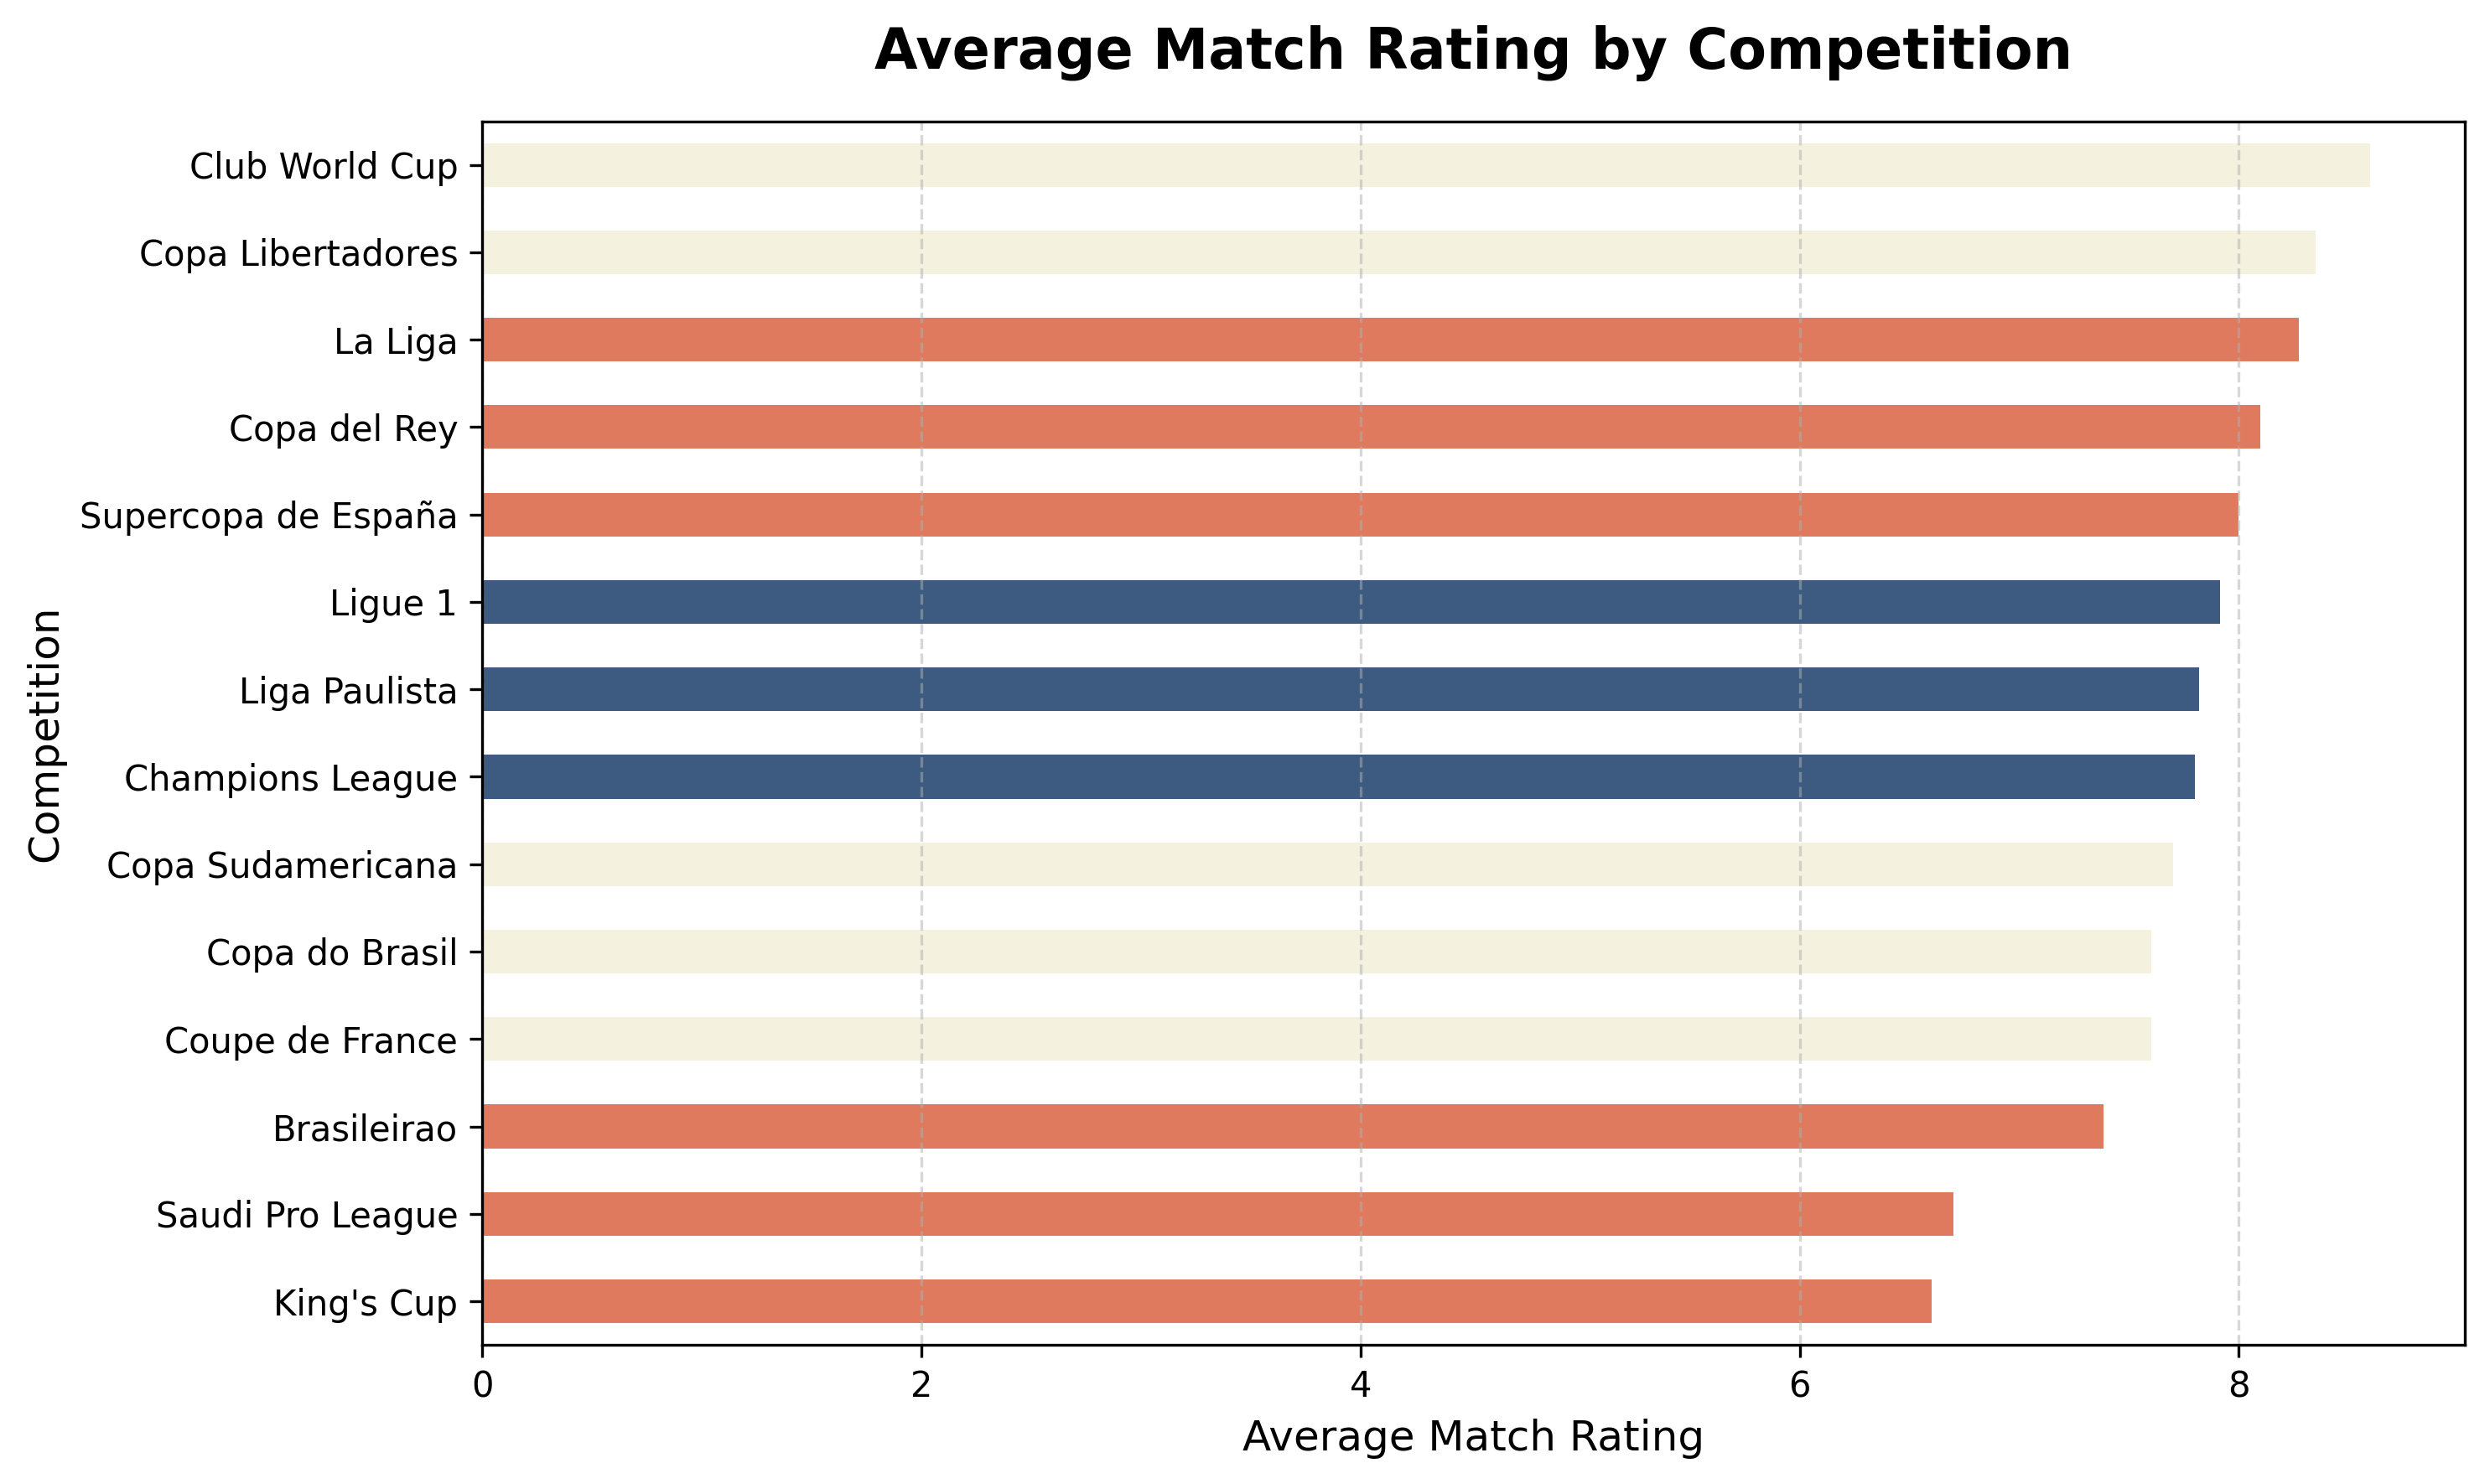

<Figure size 640x480 with 0 Axes>

In [41]:
import matplotlib.pyplot as plt

# 1. Aggregate and sort the data
competition_rating = football_df.groupby('competition')['match_rating'].mean().sort_values()

# 2. Define your color palette directly in a simple list (Assuming 9 competitions)
# 3 Red for the lowest, 3 Beige for the middle, 3 Blue for the highest
my_colors = [
    '#e07a5f', '#e07a5f', '#e07a5f',  # Lowest 3 (Terracotta Red)
    '#f4f1de', '#f4f1de', '#f4f1de',  # Middle 3 (Sand Beige)
    '#3d5a80', '#3d5a80', '#3d5a80'   # Highest 3 (Deep Ocean Blue)
]

# 3. Create the plot
plt.figure(figsize=(10,6), dpi=300) # Lowered DPI slightly so it runs faster

competition_rating.plot(
    kind='barh',
    color=my_colors,
    edgecolor='none'
)

# 4. Labels and Title
plt.title('Average Match Rating by Competition', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Match Rating', fontsize=12)
plt.ylabel('Competition', fontsize=12)

# 5. Clean up grid lines
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Save vector files
plt.savefig('competition_rating.svg', format='svg', bbox_inches='tight')
plt.savefig('competition_rating.pdf', format='pdf', bbox_inches='tight')

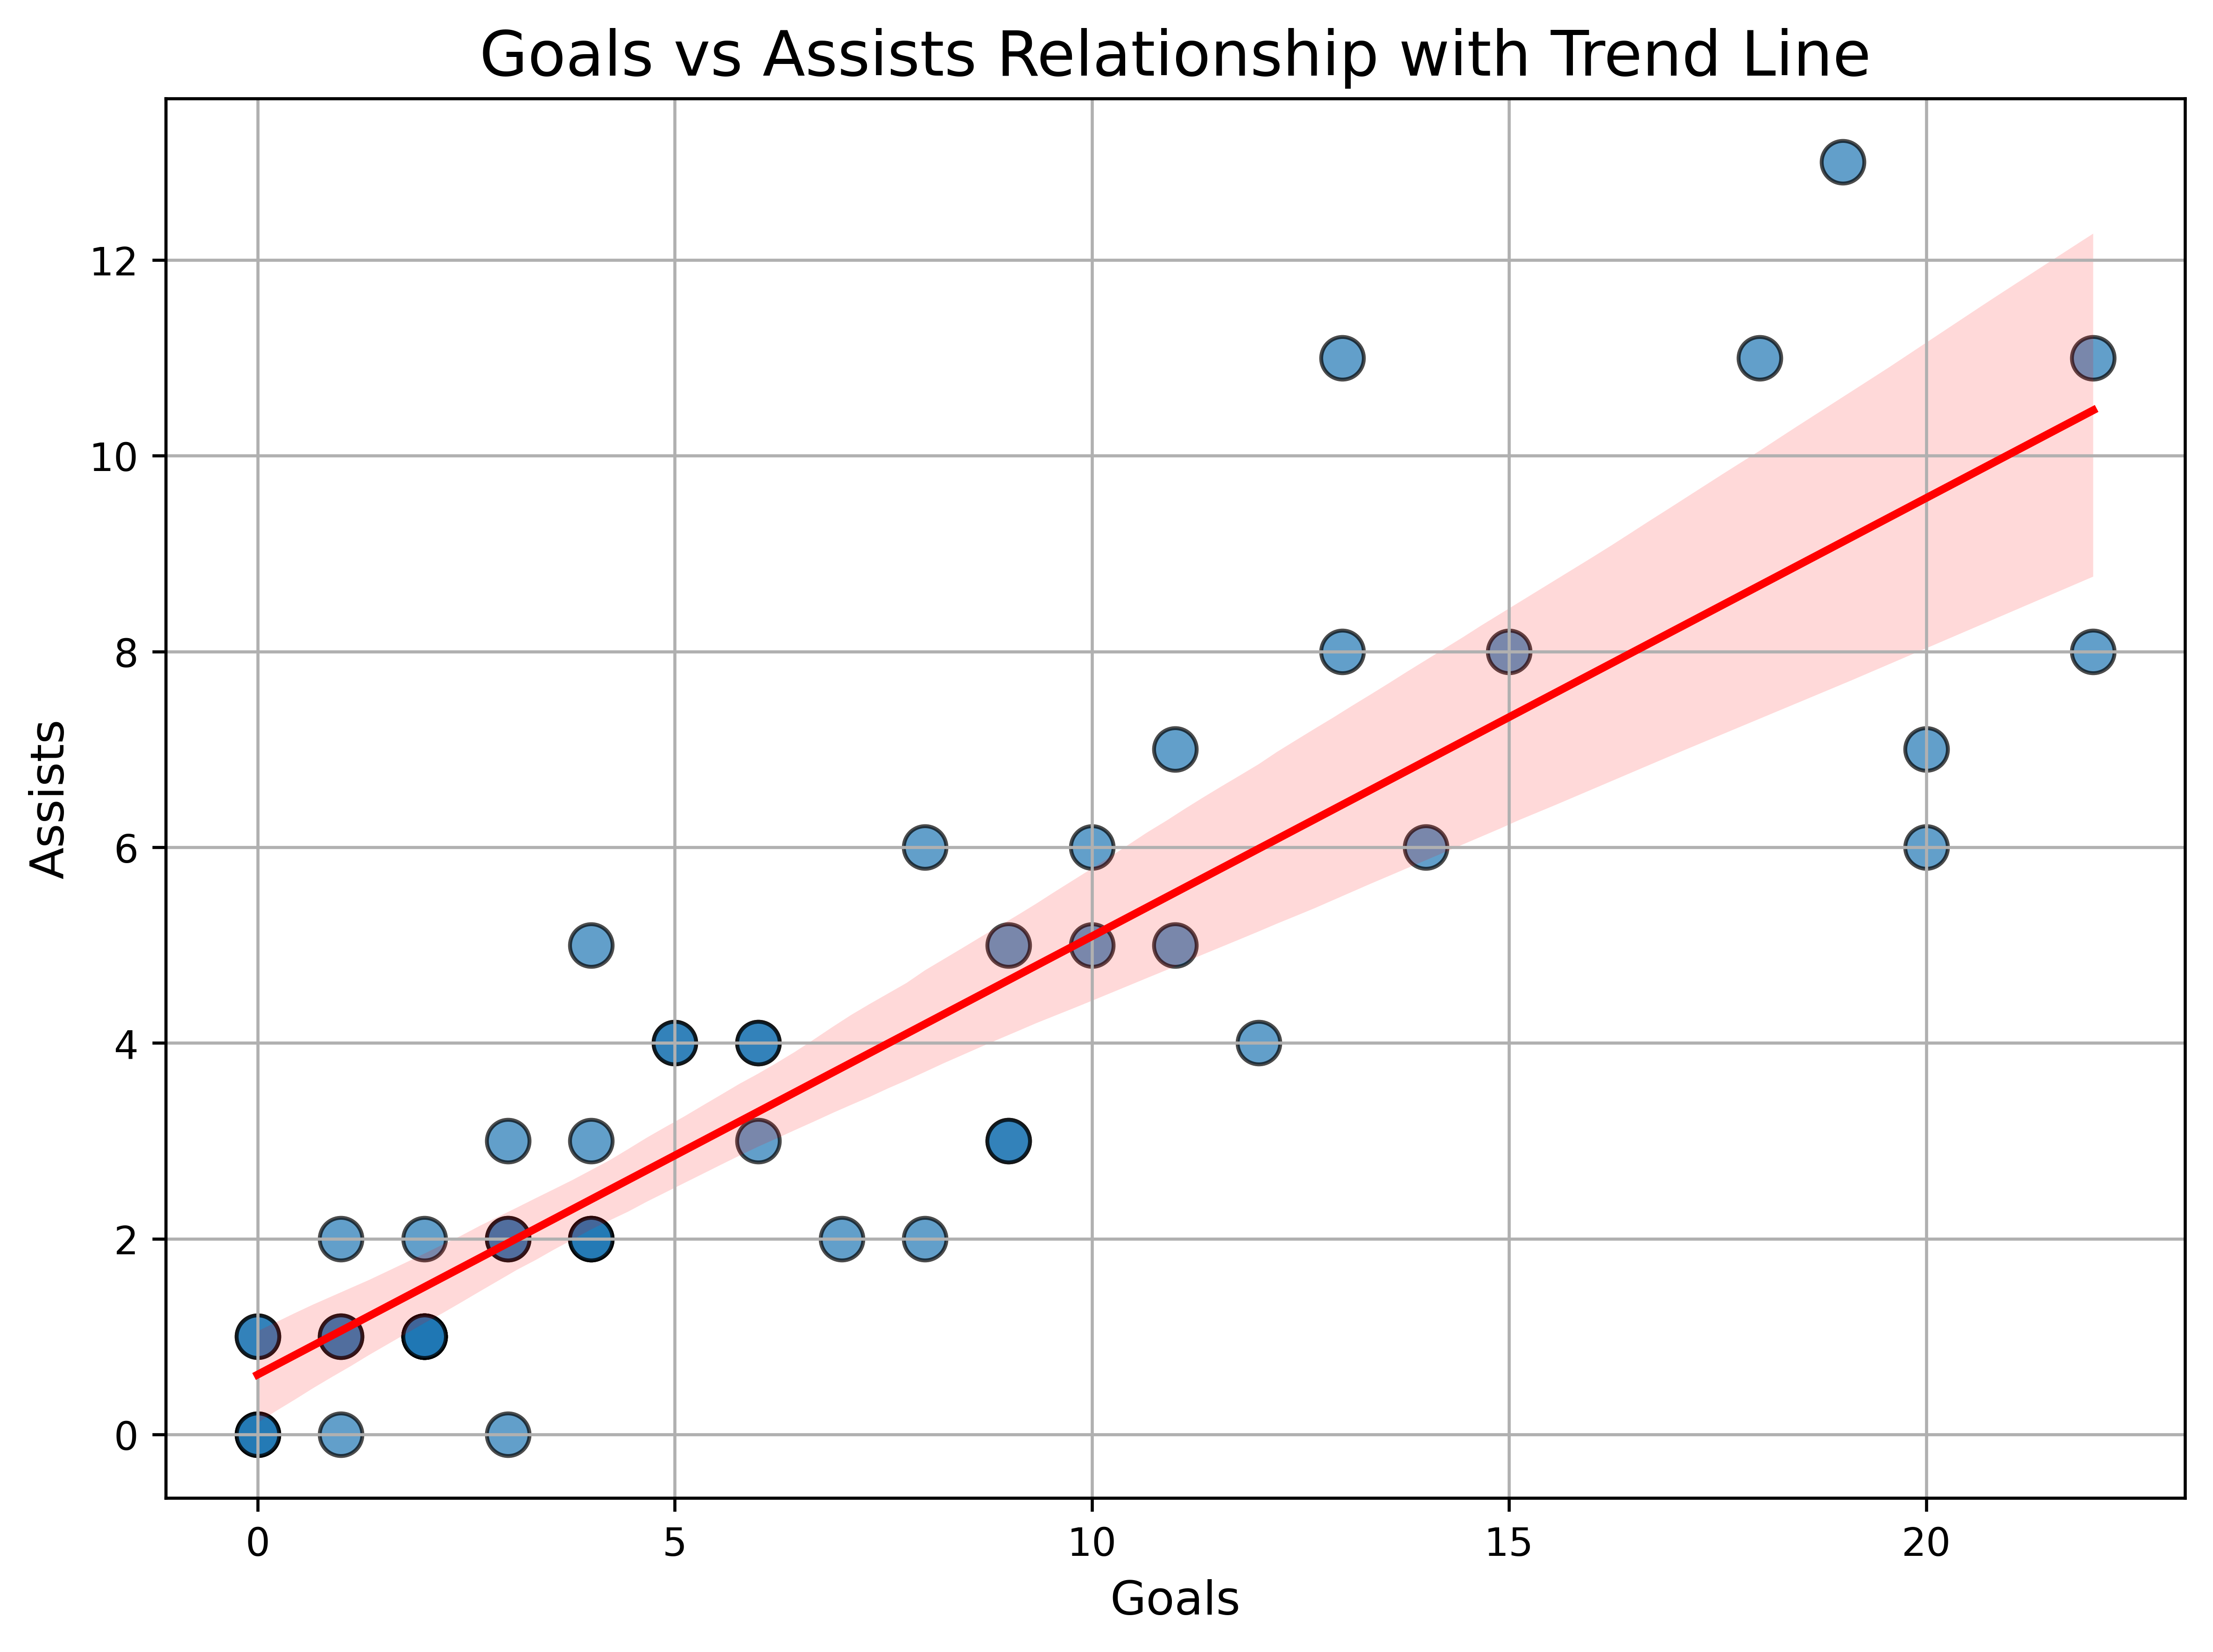

<Figure size 640x480 with 0 Axes>

In [42]:
# Goals vs Assists

plt.figure(figsize=(8,6), dpi = 600)

sns.regplot(
    x=football_df['goals'],
    y=football_df['assists'],
    scatter_kws={'s': 120, 'alpha': 0.7, 'edgecolors': 'black'},
    line_kws={'color': 'red', 'linewidth': 2},
    data=football_df
)

plt.title(
    'Goals vs Assists Relationship with Trend Line',
    fontsize=16
)

plt.xlabel(
    'Goals',
    fontsize=12
)

plt.ylabel(
    'Assists',
    fontsize=12
)

plt.grid(True)
plt.tight_layout()
plt.show()

plt.savefig('goals_assists.svg', format='svg', bbox_inches='tight')
plt.savefig('goals_assists.pdf', format='pdf', bbox_inches='tight')

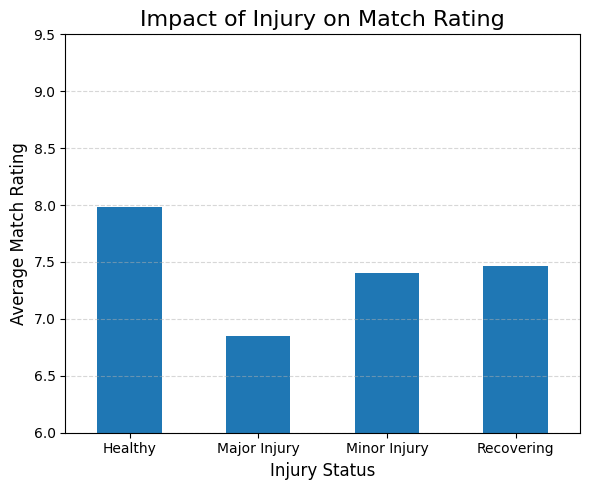

In [43]:
# Injury Impact

injury_rating = football_df.groupby(
    'injury_status'
)['match_rating'].mean()

plt.figure(figsize=(6,5))

injury_rating.plot(
    kind='bar'
)

plt.title(
    'Impact of Injury on Match Rating',
    fontsize=16
)

plt.xlabel(
    'Injury Status',
    fontsize=12
)

plt.ylabel(
    'Average Match Rating',
    fontsize=12
)

plt.ylim(6.0, 9.5)       # ← added — makes the difference more visible
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)  # ← added
plt.tight_layout()        # ← added
plt.show()

# EDA Summary

- Peak performance occurred during the MSN phase
- Injuries reduced performance consistency
- Goals and assists showed positive relationship
- Certain clubs produced stronger performance
- Career progression followed chronological stages

In [44]:
# CELL 1: INSTALL REQUIRED PACKAGES

!pip install streamlit pandas matplotlib seaborn pyngrok -q

print("✅ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 59.1 MB/s eta 0:00:00
✅ All packages installed successfully!


In [45]:
# ============================================================
# CELL 2: CREATE THE ENHANCED DASHBOARD FILE
# ============================================================
%%writefile app.py
# ============================================================
# FOOTBALL PLAYER CAREER DASHBOARD
# DATA201 Final Project — Ngai Yaw
# Enhanced Version with Heatmap & Career Success Analysis
# ============================================================

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set styling
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# ── Page Setup ────────────────────────────────────────────────────────────────
st.set_page_config(page_title="Football Career Dashboard", page_icon="⚽", layout="wide")

# ── Load Data ─────────────────────────────────────────────────────────────────
@st.cache_data
def load_data():
    football_df = pd.read_csv("football_player_career.csv")
    football_df['contribution'] = football_df['goals'] + football_df['assists']
    football_df['goal_ratio'] = football_df['goals'] / football_df['appearances']
    return football_df

football_df = load_data()

# ── Title ─────────────────────────────────────────────────────────────────────
st.title("⚽ Football Player Career Dashboard")
st.markdown("A data story about a player I admire — tracking goals, assists, trophies and injuries across 17 seasons.")
st.divider()

# ════════════════════════════════════════════════════════════
# SIDEBAR FILTERS
# ════════════════════════════════════════════════════════════
st.sidebar.title("🎛️ Filters")

# Filter 1: Club
all_clubs = ["All"] + sorted(football_df["club"].unique().tolist())
sel_club = st.sidebar.selectbox("Select Club", all_clubs)

# Filter 2: Career Phase
all_phases = ["All"] + sorted(football_df["phase"].unique().tolist())
sel_phase = st.sidebar.selectbox("Select Career Phase", all_phases)

# Filter 3: Injury Status
all_injuries = ["All"] + sorted(football_df["injury_status"].unique().tolist())
sel_injury = st.sidebar.selectbox("Select Injury Status", all_injuries)

# Apply filters
filtered = football_df.copy()
if sel_club != "All":
    filtered = filtered[filtered["club"] == sel_club]
if sel_phase != "All":
    filtered = filtered[filtered["phase"] == sel_phase]
if sel_injury != "All":
    filtered = filtered[filtered["injury_status"] == sel_injury]

st.sidebar.divider()
st.sidebar.write(f"📋 Showing **{len(filtered)}** rows out of {len(football_df)}")

# ════════════════════════════════════════════════════════════
# SECTION 1: STORY OVERVIEW
# ════════════════════════════════════════════════════════════
st.header("📖 Story Overview")
st.markdown("""
This project explores the career journey of a professional football athlete through data
analysis and visualization.

The dataset was designed to analyze **performance trends** across different seasons,
competitions, and clubs. The project examines factors related to:
- ✅ Success and peak career years
- 📉 Decline periods
- 📊 Overall performance consistency

The dataset follows a **chronological career progression** — from early development
at Santos, through peak performance at Barcelona, the PSG era, a difficult period
at Al-Hilal, and finally a return to Santos in 2025.

The purpose of this analysis is to understand how different factors — such as injury
status, club environment, and competition level — may influence **long-term success
in professional football**, and to communicate these insights through an interactive dashboard.

The dataset covers **50 rows** across **17 seasons**, split by competition, tracking:
goals, assists, trophies, match rating, and injury status.
""")

# 4 simple KPI metrics
c1, c2, c3, c4 = st.columns(4)
c1.metric("⚽ Total Goals", int(filtered["goals"].sum()))
c2.metric("🎯 Total Assists", int(filtered["assists"].sum()))
c3.metric("🏆 Trophies Won", int(filtered["trophies_won"].sum()))
c4.metric("⭐ Avg Match Rating", f"{filtered['match_rating'].mean():.2f}")

st.divider()

# ════════════════════════════════════════════════════════════
# SECTION 2: CAREER SUCCESS YEARS ANALYSIS
# ════════════════════════════════════════════════════════════
st.header("🌟 Career Success Years Analysis")

# Define success years based on goals and rating
season_performance = football_df.groupby('season').agg({
    'goals': 'sum',
    'assists': 'sum',
    'match_rating': 'mean',
    'trophies_won': 'sum',
    'contribution': 'sum'
}).reset_index()

season_performance['season'] = season_performance['season'].astype(int).astype(str)

# Create success score (normalized composite metric)
season_performance['success_score'] = (
    (season_performance['goals'] / season_performance['goals'].max() * 0.3) +
    (season_performance['assists'] / season_performance['assists'].max() * 0.2) +
    (season_performance['match_rating'] / 10 * 0.3) +
    (season_performance['trophies_won'] / season_performance['trophies_won'].max() * 0.2)
) * 100

# Identify peak years (top 30% success score)
threshold = season_performance['success_score'].quantile(0.70)
peak_years = season_performance[season_performance['success_score'] >= threshold]['season'].tolist()

col1, col2 = st.columns([2, 1])

with col1:
    st.subheader("Success Score Over Time")
    fig_success, ax_success = plt.subplots(figsize=(12, 5))

    colors = ['red' if score >= threshold else 'steelblue'
              for score in season_performance['success_score']]

    ax_success.bar(season_performance['season'], season_performance['success_score'],
                   color=colors, edgecolor='black', linewidth=0.8, alpha=0.8)
    ax_success.axhline(y=threshold, color='darkred', linestyle='--', linewidth=2,
                       label=f'Peak Threshold ({threshold:.1f})', alpha=0.7)

    ax_success.set_xlabel("Season", fontsize=12, fontweight='bold')
    ax_success.set_ylabel("Success Score", fontsize=12, fontweight='bold')
    ax_success.set_title("Career Success Score by Season (Composite Metric)",
                         fontsize=14, fontweight='bold', pad=20)
    ax_success.legend(fontsize=10)
    ax_success.grid(True, axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    st.pyplot(fig_success)

with col2:
    st.subheader("Peak Years")
    st.markdown(f"""
    **🔥 Peak Career Years:**
    {', '.join(map(str, peak_years))}

    **📊 Success Score Calculation:**
    - 30% Goals
    - 20% Assists
    - 30% Match Rating
    - 20% Trophies

    **🎯 Threshold:** Top 30% of seasons

    Red bars indicate **peak performance years** where the player achieved exceptional success across all metrics.
    """)

st.caption("📌 Success score combines multiple performance indicators to identify career peak years objectively.")
st.divider()

# ════════════════════════════════════════════════════════════
# SECTION 3: VISUALIZATIONS
# ════════════════════════════════════════════════════════════
st.header("📊 Data Visualizations")

# ── Chart 1: Goals Over Seasons ───────────────────────────────────────────────
st.subheader("1. Goals Over Seasons")

season_goals = filtered.groupby("season")["goals"].sum()

fig1, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(season_goals.index, season_goals.values, marker="o", color="steelblue",
         linewidth=2, markersize=8)
ax1.fill_between(season_goals.index, season_goals.values, alpha=0.2, color="steelblue")
ax1.set_xlabel("Season", fontsize=12, fontweight='bold')
ax1.set_ylabel("Goals", fontsize=12, fontweight='bold')
ax1.set_title("Total Goals Per Season", fontsize=14, fontweight='bold', pad=20)
ax1.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
st.pyplot(fig1)
st.caption("📌 Line chart shows how goals changed season by season. Peaks show best years; dips often link to injuries.")

st.markdown("---")

# ── Chart 2: Match Rating by Competition (IMPROVED) ───────────────────────────
st.subheader("2. Average Match Rating by Competition")

comp_rating = filtered.groupby("competition")["match_rating"].mean().sort_values()

if comp_rating.empty:
    st.warning("No data available for this chart. Adjust your filters.")
else:
    fig2, ax2 = plt.subplots(figsize=(10, 5))

    # Create color gradient
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(comp_rating)))

    bars = ax2.barh(comp_rating.index, comp_rating.values, color=colors,
                    edgecolor='black', linewidth=0.8)

    # Add value labels
    for i, (idx, val) in enumerate(comp_rating.items()):
        ax2.text(val + 0.05, i, f'{val:.2f}', va='center', fontweight='bold', fontsize=10)

    ax2.set_xlabel("Average Match Rating", fontsize=12, fontweight='bold')
    ax2.set_ylabel("Competition", fontsize=12, fontweight='bold')
    ax2.set_title("Average Match Rating by Competition", fontsize=14, fontweight='bold', pad=20)
    ax2.axvline(x=7.5, color="red", linestyle="--", linewidth=2,
                label="7.5 threshold", alpha=0.7)
    ax2.legend(fontsize=10)
    ax2.set_xlim(6.5, comp_rating.max() + 0.5)

    # Style spines
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    st.pyplot(fig2)
    st.caption("📌 Bar chart compares performance across different competitions. Color gradient shows rating strength (red=lower, green=higher).")

st.markdown("---")

# ── Chart 3 & 4 side by side ──────────────────────────────────────────────────
col_left, col_right = st.columns(2)

with col_left:
    st.subheader("3. Goals vs Assists")

    fig3, ax3 = plt.subplots(figsize=(6, 5))
    ax3.scatter(filtered["goals"], filtered["assists"], s=100,
                color="mediumseagreen", edgecolors="black",
                linewidth=1, alpha=0.7)
    ax3.set_xlabel("Goals", fontsize=11, fontweight='bold')
    ax3.set_ylabel("Assists", fontsize=11, fontweight='bold')
    ax3.set_title("Goals vs Assists", fontsize=13, fontweight='bold', pad=15)
    ax3.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    st.pyplot(fig3)
    st.caption("📌 Scatter plot shows relationship between goals and assists. Top-right = best all-round performances.")

with col_right:
    st.subheader("4. Trophies Won by Club")

    club_trophies = filtered.groupby("club")["trophies_won"].sum().sort_values(ascending=False)

    fig4, ax4 = plt.subplots(figsize=(6, 5))
    ax4.bar(club_trophies.index, club_trophies.values, color="mediumpurple",
            edgecolor="black", linewidth=0.8)
    for i, v in enumerate(club_trophies.values):
        ax4.text(i, v + 0.2, str(int(v)), ha="center", fontweight="bold", fontsize=11)
    ax4.set_xlabel("Club", fontsize=11, fontweight='bold')
    ax4.set_ylabel("Trophies Won", fontsize=11, fontweight='bold')
    ax4.set_title("Trophies Won by Club", fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    st.pyplot(fig4)
    st.caption("📌 Bar chart shows which club brought the most trophies.")

st.markdown("---")

# ── Chart 5: Injury Status vs Match Rating ────────────────────────────────────
st.subheader("5. Injury Impact on Match Rating")

injury_order = ["Healthy", "Minor Injury", "Recovering", "Major Injury"]
avail = [x for x in injury_order if x in filtered["injury_status"].values]
injury_rating = filtered.groupby("injury_status")["match_rating"].mean().reindex(avail)

colors5 = ["green", "orange", "steelblue", "red"][:len(avail)]

fig5, ax5 = plt.subplots(figsize=(10, 4))
bars = ax5.bar(injury_rating.index, injury_rating.values, color=colors5,
               edgecolor="black", width=0.6, linewidth=0.8)
for bar in bars:
    ax5.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f"{bar.get_height():.2f}",
             ha="center", fontweight="bold", fontsize=11)
ax5.set_xlabel("Injury Status", fontsize=12, fontweight='bold')
ax5.set_ylabel("Average Match Rating", fontsize=12, fontweight='bold')
ax5.set_title("Impact of Injury on Match Rating", fontsize=14, fontweight='bold', pad=20)
ax5.set_ylim(6.0, 9.5)
ax5.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
st.pyplot(fig5)
st.caption("📌 Clear pattern — when healthy, rating is highest. Major injuries cause biggest performance drop.")

st.markdown("---")

# ── Chart 6: HEATMAP - Goals by Season and Club ───────────────────────────────
st.subheader("6. Performance Heatmap: Goals by Season and Club")

heatmap_data = filtered.pivot_table(
    values='goals',
    index='club',
    columns='season',
    aggfunc='sum',
    fill_value=0
)

if heatmap_data.empty or heatmap_data.shape[0] == 0:
    st.warning("No data available for heatmap. Adjust your filters.")
else:
    fig6, ax6 = plt.subplots(figsize=(14, 6))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.0f',
        cmap='YlOrRd',
        linewidths=0.8,
        linecolor='white',
        cbar_kws={'label': 'Goals Scored'},
        ax=ax6,
        vmin=0,
        square=False,
        annot_kws={"fontsize": 10, "fontweight": "bold"}
    )

    ax6.set_title("Goals Scored by Club and Season", fontsize=14, fontweight='bold', pad=20)
    ax6.set_xlabel("Season", fontsize=12, fontweight='bold')
    ax6.set_ylabel("Club", fontsize=12, fontweight='bold')

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    st.pyplot(fig6)
    st.caption("📌 Heatmap shows goal distribution across seasons and clubs. Darker red = more goals. Easy to spot peak years at each club.")

st.markdown("---")

# ── Chart 7: HEATMAP - Match Rating by Phase and Competition ──────────────────
st.subheader("7. Match Rating Heatmap: Career Phase vs Competition")

heatmap_rating = filtered.pivot_table(
    values='match_rating',
    index='phase',
    columns='competition',
    aggfunc='mean'
)

if not heatmap_rating.empty:
    fig7, ax7 = plt.subplots(figsize=(12, 6))

    sns.heatmap(
        heatmap_rating,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=1,
        linecolor='gray',
        cbar_kws={'label': 'Avg Rating'},
        ax=ax7,
        center=7.5,
        vmin=6.5,
        vmax=9.0,
        annot_kws={"fontsize": 9, "fontweight": "bold"}
    )

    ax7.set_title("Average Match Rating by Career Phase and Competition",
                  fontsize=14, fontweight='bold', pad=20)
    ax7.set_xlabel("Competition", fontsize=12, fontweight='bold')
    ax7.set_ylabel("Career Phase", fontsize=12, fontweight='bold')

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    st.pyplot(fig7)
    st.caption("📌 Shows which competitions performed best in each career phase. Blue=lower rating, Red=higher rating.")
else:
    st.info("Not enough data for this heatmap with current filters.")

st.divider()

# ════════════════════════════════════════════════════════════
# SECTION 4: KEY INSIGHTS
# ════════════════════════════════════════════════════════════
st.header("🔍 Key Insights")

best_row = filtered.loc[filtered["goals"].idxmax()] if not filtered.empty else None
healthy_avg = football_df[football_df["injury_status"] == "Healthy"]["match_rating"].mean()
injury_avg = football_df[football_df["injury_status"] == "Major Injury"]["match_rating"].mean()

if best_row is not None:
    st.success(f"🔥 Best scoring period: **{int(best_row['season'])}** — {best_row['competition']} at {best_row['club']} with **{int(best_row['goals'])} goals**")

st.info(f"🏥 Healthy seasons average **{healthy_avg:.2f}** rating vs **{injury_avg:.2f}** during major injuries — a **{abs(healthy_avg - injury_avg):.2f} point drop**.")
st.info(f"👑 Peak career years ({', '.join(map(str, peak_years))}) produced the highest combined performance across all metrics.")
st.info("📈 Career growth from 2009–2015 is steep — goals and ratings both improved every healthy season.")
st.info("🔄 The 2025 Santos return shows recovery — ratings above 7.5 with improving injury status.")
st.info("🏆 Barcelona era (2013-2021) accounts for the majority of career trophies and highest average ratings.")

st.divider()

# ════════════════════════════════════════════════════════════
# SECTION 5: DECISION-MAKING
# ════════════════════════════════════════════════════════════
st.header("🎯 Decision-Making")

st.markdown(f"""
**Based on my data, what should this player do differently?**

**1. 🏥 Prioritize injury prevention above all else.**
The data is unambiguous: healthy seasons rate **{healthy_avg:.2f}** vs **{injury_avg:.2f}** when seriously injured.
The {abs(healthy_avg - injury_avg):.2f} point drop translates directly to performance decline.
Staying fit matters more than any transfer or tactical change.

**2. ⏱️ Consistent playing time builds peak performance.**
The success score analysis reveals that the highest-performing seasons all feature the most appearances.
Playing regularly — even at a smaller club — consistently outperforms sitting on the bench at a bigger club.

**3. 🏟️ Environment matters: Choose clubs that fit career phase.**
The heatmap shows clear performance patterns:
- Peak years (2013-2017) at Barcelona with familiar system
- Decline during PSG/Al-Hilal transition periods
- Recovery at Santos with guaranteed playing time

**4. 🔄 The 2025 Santos return validates the data-driven approach.**
A familiar environment with guaranteed game time matches the proven formula from earlier Santos years.
Early 2025 data shows ratings above 7.5 and improving injury status — confirming the strategy.

**5. 🎯 Focus on competitions that historically show best ratings.**
The rating-by-competition heatmap identifies which tournaments consistently produce better performances.
Strategic rest during lower-priority competitions could preserve fitness for key matches.

⚠️ **LIMITATIONS:**
- These are data-supported observations from 50 rows, not definitive conclusions
- Team quality, coaching philosophy, and personal factors are not captured
- The dataset combines competitions of varying difficulty levels
- Small sample size limits statistical confidence
- Correlation does not imply causation
""")

st.divider()

# ════════════════════════════════════════════════════════════
# SECTION 6: ETHICS & RESPONSIBILITY
# ════════════════════════════════════════════════════════════
st.header("⚖️ Ethics & Responsibility")

with st.expander("🔒 Privacy Statement"):

    st.markdown("""

**What data is included?**
- Publicly available football statistics and sports analytics information
- Performance metrics such as goals, assists, appearances, and match ratings
- Competition and club performance information
- General injury status categories
- Trophy statistics

**What is anonymized?**
- The athlete is not directly identified in the dashboard
- No private, medical, financial, or contract information is included
- No personally identifiable information (PII) is included
- The dataset was designed for DATA201 educational purposes

**Ethical Data Use**
- The analysis focuses on football performance trends rather than personal life
- Some variables and career phases include subjective interpretation
- The findings are exploratory and should not be interpreted as official professional statistics

""")

with st.expander("⚠️ Bias & Limitation Disclosure"):
    st.markdown("""
**Known Biases:**

1. **Aggregation Bias**
   - Season totals combine competitions of vastly different difficulty
   - Champions League vs Domestic Cup goals are treated equally
   - Does not account for opponent strength or match importance

2. **Selection Bias**
   - International matches (World Cup, Copa América) not included
   - Only club performances analyzed
   - May miss important career context

3. **Temporal Bias**
   - Recent seasons may be remembered more vividly
   - Historical context (rule changes, tactical evolution) not captured

4. **Labeling Bias**
   - Phase names like "MSN Peak" reflect personal interpretation
   - Injury status categories are simplified (reality is more complex)
   - "Success score" weights are subjectively chosen

5. **Small Dataset Limitations**
   - 50 rows is enough for trends but limits statistical proof
   - Cannot control for confounding variables
   - Patterns may be coincidental rather than causal

6. **Missing Variables**
   - Team quality and tactical system not captured
   - Coaching style and management influence excluded
   - Personal life events and motivation not tracked
   - Market value and financial incentives missing

7. **Confirmation Bias Risk**
   - Personal admiration for this player may influence interpretation
   - Tendency to see patterns that confirm pre-existing beliefs
   - Dashboard creator's fandom may affect narrative framing
    """)

with st.expander("📊 Visualization Justification"):
    st.markdown("""
| Chart | Type | Why This Type? | Risk of Misinterpretation |
|---|---|---|---|
| **Goals Over Seasons** | Line Chart | Shows continuous trend over time; makes growth/decline patterns immediately visible | Y-axis doesn't start at zero — could exaggerate changes |
| **Rating by Competition** | Horizontal Bar | Easy comparison across categories; horizontal layout accommodates long names | Color gradient might imply causation where there's only correlation |
| **Goals vs Assists** | Scatter Plot | Reveals relationship between two continuous variables; outliers are visible | Doesn't show causation; overlapping points hidden |
| **Trophies by Club** | Vertical Bar | Simple comparison of discrete counts; values labeled clearly | Doesn't account for team quality differences |
| **Injury Impact** | Grouped Bar | Direct comparison between categories; color-coded for intuitive understanding | Small sample size per category limits confidence |
| **Goals Heatmap** | Heatmap | Shows two-dimensional patterns; color intensity reveals peaks instantly | Missing data (zeros) vs no data looks the same |
| **Rating Heatmap** | Heatmap | Compares performance across two categorical dimensions simultaneously | Averages hide variance; small sample sizes not visible |
| **Success Score** | Bar Chart with Threshold | Composite metric makes peak years objective; threshold clearly identifies top 30% | Weights (30% goals, 20% assists, etc.) are arbitrary |

**Why These Charts Were Chosen:**
- Prioritized clarity over complexity — audience is non-technical
- Used color strategically (red for injury/low, green for healthy/high)
- Avoided 3D charts, pie charts, and misleading axes
- Each chart answers a specific analytical question
- Interactive filters allow personalized exploration
    """)

with st.expander("🎯 Responsible Decision Statement"):
    st.markdown("""
**Critical Context for Decision-Making Section:**

✅ **What the data CAN support:**
- Injury prevention correlates with better performance (strong pattern)
- Playing time correlates with higher output (clear trend)
- Familiar environments show consistent ratings (observable pattern)

❌ **What the data CANNOT prove:**
- Causation (correlation ≠ causation)
- Future performance predictions (past ≠ future)
- Optimal career decisions (too many unmeasured variables)

**Limitations Acknowledged:**
1. **50-row dataset** — results are exploratory, not conclusive
2. **Missing context** — team quality, tactics, personal factors unknown
3. **Subjective weighting** — "success score" formula is one possible approach
4. **Confirmation bias** — creator's admiration for player may influence interpretation
5. **Hindsight bias** — analyzing past decisions with knowledge of outcomes

**Responsible Use:**
- Decisions are **observations from data**, not prescriptive advice
- Should be combined with expert coaching/medical input
- Personal player preferences and goals matter more than statistics
- Data informs but should not solely dictate career choices

**Transparency Commitment:**
- All analysis code and data available for review
- Methodology clearly documented
- Limitations prominently disclosed
- Alternative interpretations acknowledged
    """)

st.divider()

# ════════════════════════════════════════════════════════════
# FOOTER
# ════════════════════════════════════════════════════════════
st.caption("📊 Dashboard by Ngai Yaw · DATA201 Final Project · May 2026 · Player identity anonymized")
st.caption("Data sources: Wikipedia, FotMob, Transfermarkt (public domain)")
st.caption("⚠️ For academic purposes only · Not for commercial use")

Writing app.py


In [46]:
# ============================================================
# CELL 3: SETUP NGROK AUTHENTICATION
# ============================================================
# Replace with your actual ngrok token from https://ngrok.com/
!ngrok authtoken 39qHPjikPQXttm0MrjokPR5hS2M_61HNeq9kL2qH1c6eQ4A4p

print("✅ Ngrok authenticated!")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
✅ Ngrok authenticated!


In [47]:
import time
from pyngrok import ngrok

# 1. Kill any hidden system processes running ngrok in the background
!pkill -f ngrok

# 2. Reset the pyngrok configuration tracker
ngrok.kill()

# 3. Start Streamlit in background
get_ipython().system_raw('streamlit run app.py --server.port 8501 &')

# 4. Wait for Streamlit to start up completely
time.sleep(5)

# 5. Connect and generate your public URL
try:
    public_url = ngrok.connect(8501)
    print("=" * 70)
    print(f"🌐 YOUR STREAMLIT APP IS LIVE!")
    print(f"🔗 Click here: {public_url}")
    print("=" * 70)
    print("\n📌 Keep this cell running to keep the app alive")
    print("📌 To stop the app: Interrupt the kernel")
except Exception as e:
    print(f"❌ Connection failed. If you still see ERR_NGROK_334, please use Solution 1 to clear it from the dashboard.")

🌐 YOUR STREAMLIT APP IS LIVE!
🔗 Click here: NgrokTunnel: "https://premillennially-oosporic-beulah.ngrok-free.dev" -> "http://localhost:8501"

📌 Keep this cell running to keep the app alive
📌 To stop the app: Interrupt the kernel
